Extracting parameters from Data/Test1\FD_sponge1.vhdr...
Setting channel info structure...
Reading 0 ... 461699  =      0.000 ...   461.699 secs...
Used Annotations descriptions: ['Comment/ce', 'Comment/ec', 'Comment/eo', 'New Segment/', 'Stimulus/S  7']

🔄 Found 118 events with 5 unique event types
Event dictionary: {'Comment/ce': 10001, 'Comment/ec': 10002, 'Comment/eo': 10003, 'New Segment/': 99999, 'Stimulus/S  7': 7}

⚙️ Special Channels:
- paste_eeg: 14

✅ EEG Info:
- Channels: 11
- Channel names: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
- Duration: 461.70 sec
- Sampling Rate: 1000.0 Hz

📏 Global Signal STD (µV): 259.7215

========== CONTINUOUS EEG ANALYSIS ==========
    Using multitaper spectrum estimation with 1 DPSS windows


C:\Users\mhfar\AppData\Local\Temp\ipykernel_35772\2225489808.py:78: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  psd = data_obj.compute_psd(fmax=fmax, method='multitaper')



⚡ Band Power (total across all channels):
- Delta (0.5–4 Hz): 0.00012933
- Theta (4–8 Hz): 0.00003407
- Alpha (8–12 Hz): 0.00001643
- Beta (12–30 Hz): 0.00001981
- Gamma (30–50 Hz): 0.00000882

📊 Relative Band Power (%):
- Delta (0.5–4 Hz): 62.04%
- Theta (4–8 Hz): 16.34%
- Alpha (8–12 Hz): 7.88%
- Beta (12–30 Hz): 9.50%
- Gamma (30–50 Hz): 4.23%

📶 SNR Metrics:
- Alpha/Gamma SNR: 1.86
- Alpha/Beta SNR: 0.83

========== VEP ANALYSIS WITH ARTIFACT REJECTION ==========

🔍 Processing epochs for trigger: Stimulus/S  7
Not setting metadata
110 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 110 events and 701 original time points ...
    Rejecting  epoch based on EEG : ['5']
    Rejecting  epoch based on EEG : ['5']
    Rejecting  epoch based on EEG : ['5']
    Rejecting  epoch based on EEG : ['5']
    Rejecting  epoch based on EEG : ['5']
    Rejecting  epoch based on EEG : ['5']
    Rejecting  epoch based on E

C:\Users\mhfar\AppData\Local\Temp\ipykernel_35772\2225489808.py:322: RuntimeWarning: filter_length (3301) is longer than the signal (701), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_vep = epochs.copy().filter(1, 30, method='fir')
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.0s


    Using multitaper spectrum estimation with 7 DPSS windows
Could not compute PSD for epochs: boolean index did not match indexed array along dimension 1; dimension is 11 but corresponding boolean dimension is 36

========== ALPHA WAVE ANALYSIS ==========
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 1651 samples (1.651 s)

Effective window size : 2.048 (s)

🧠 Alpha Wave Metrics (Sorted by Alpha Power %):
Channel  Mean Amplitude (µV)  Max Amplitude (µV)  Std Dev (µV)  Alpha Power (%) Channel Type
     1

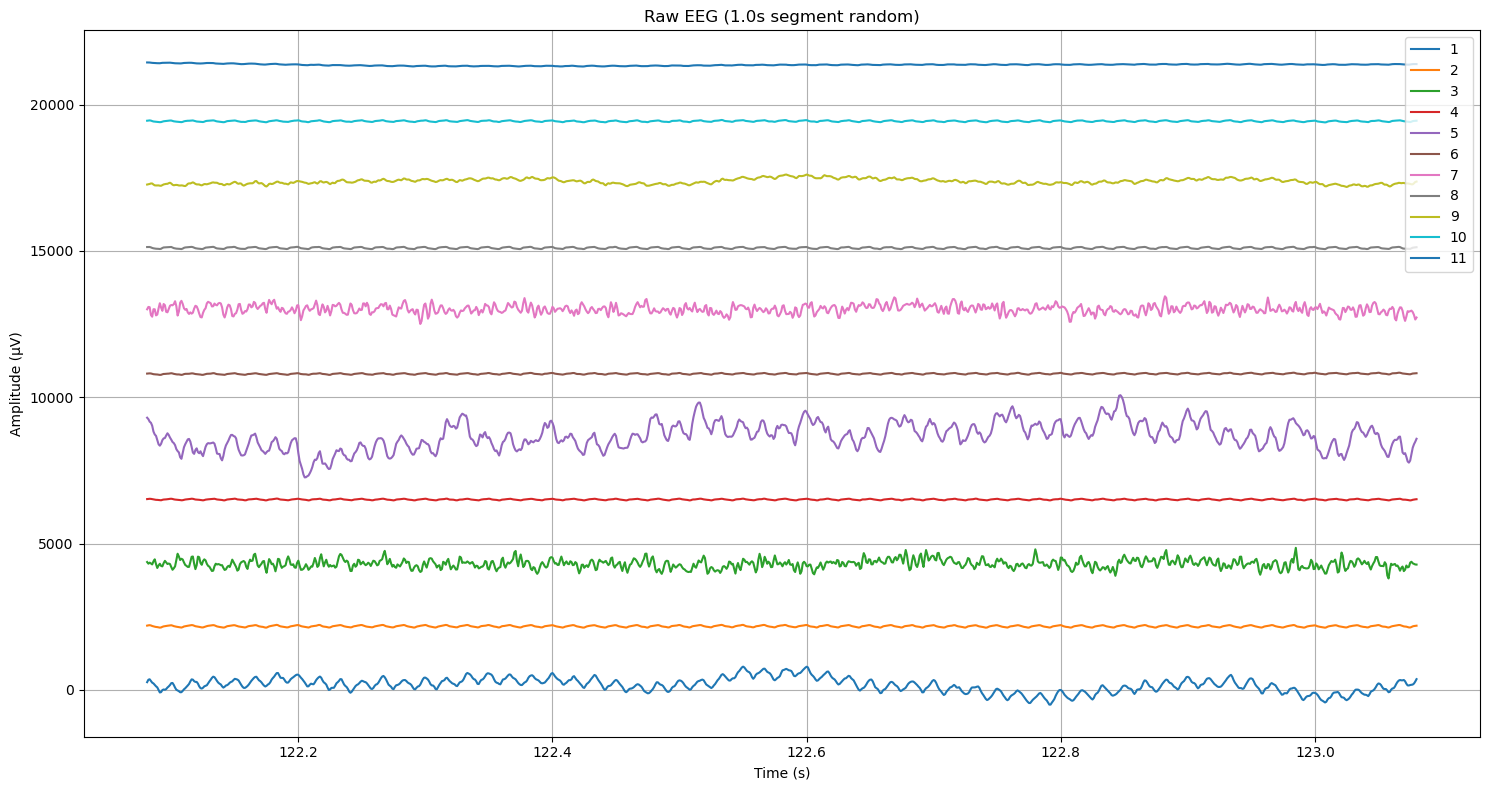

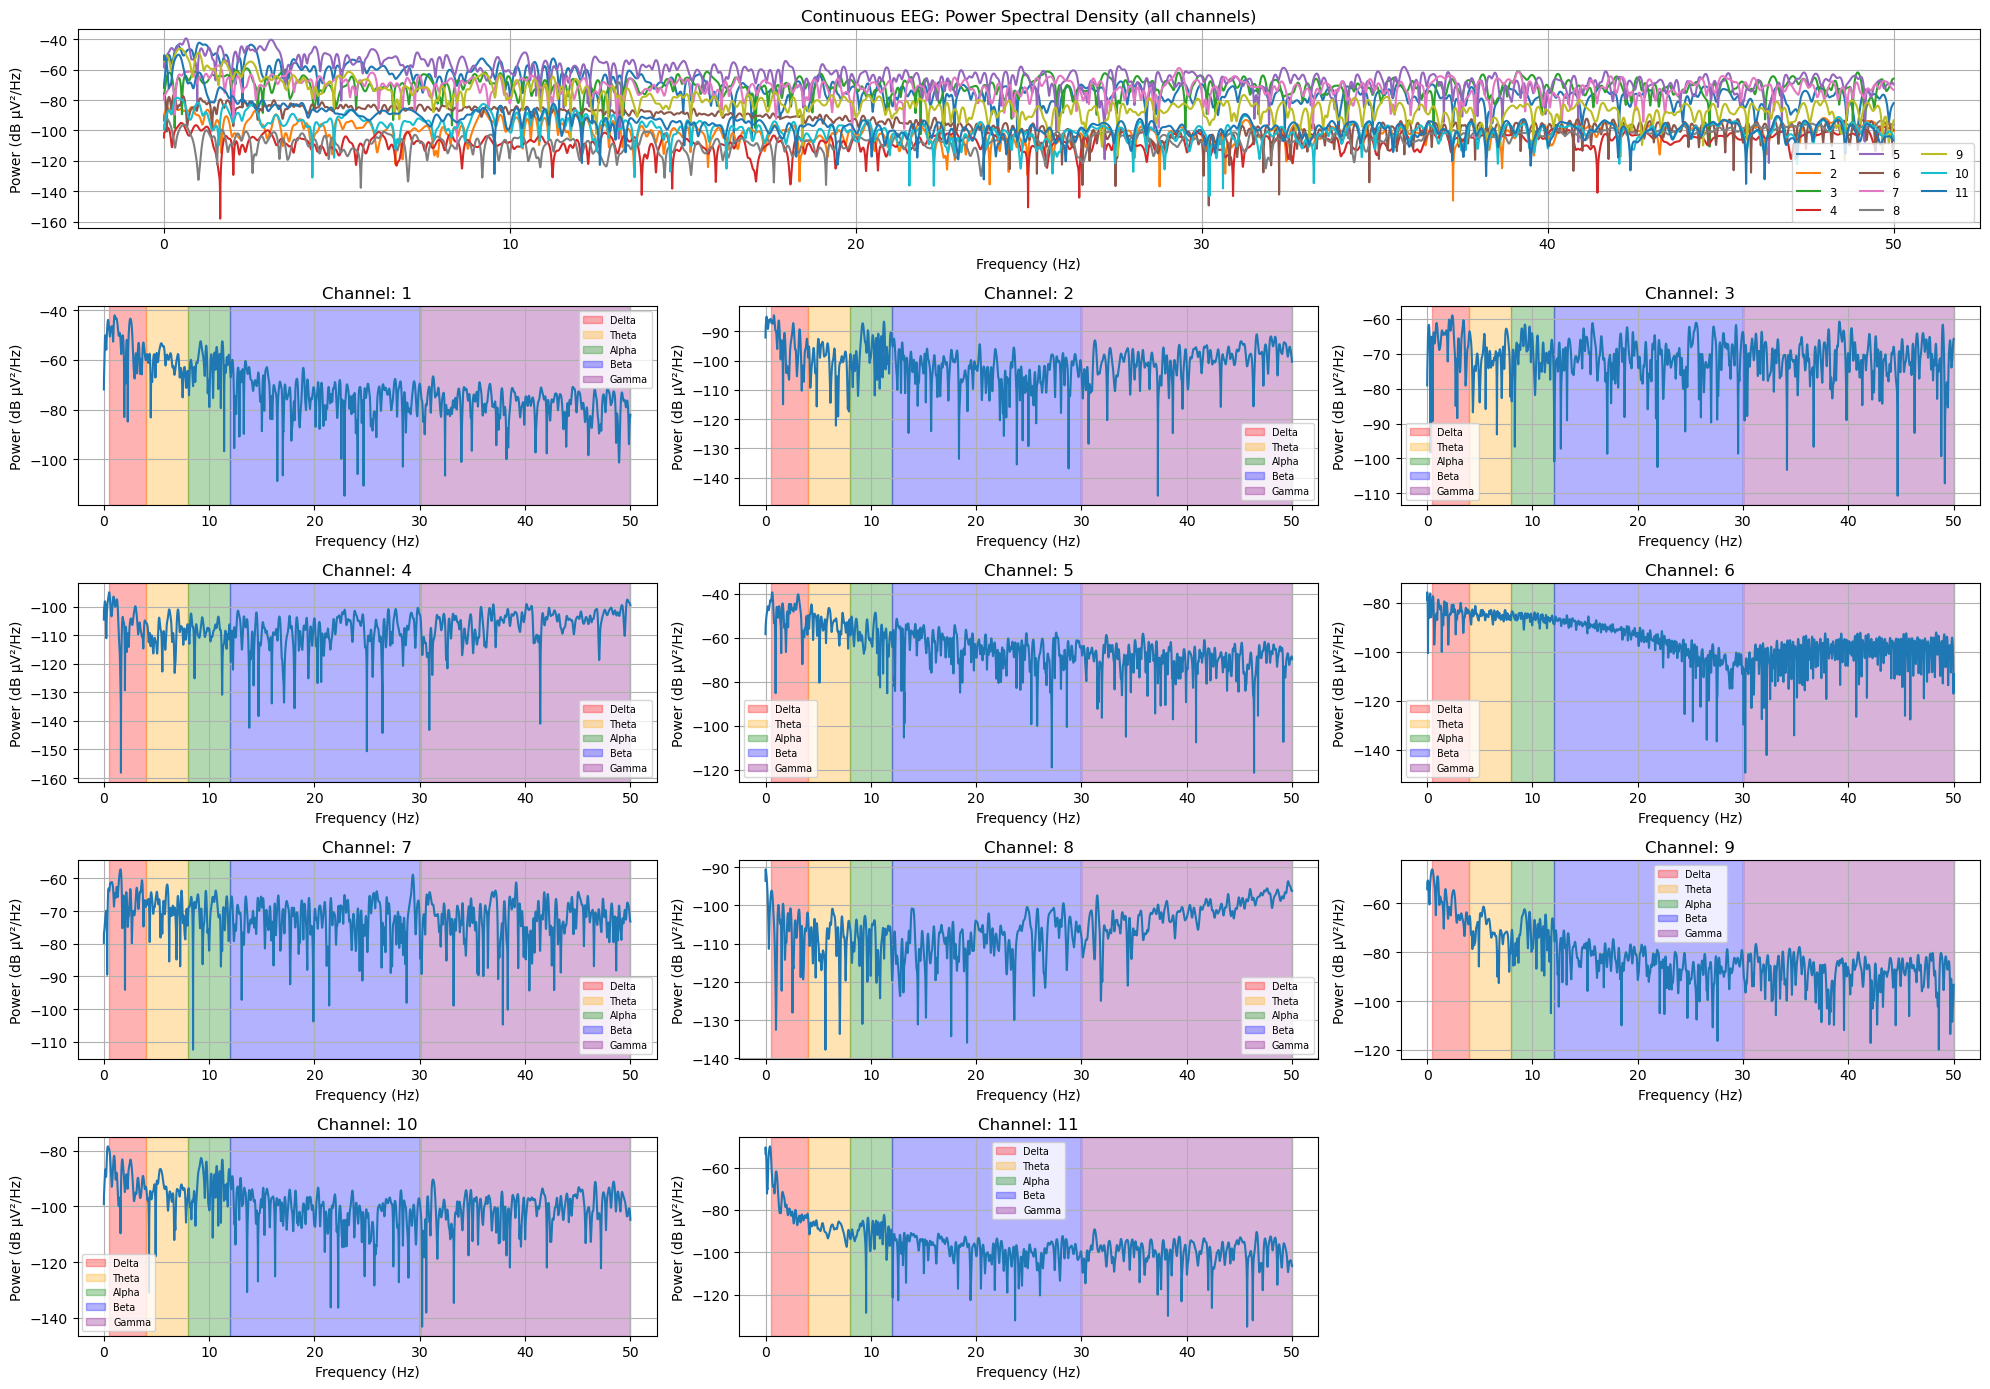

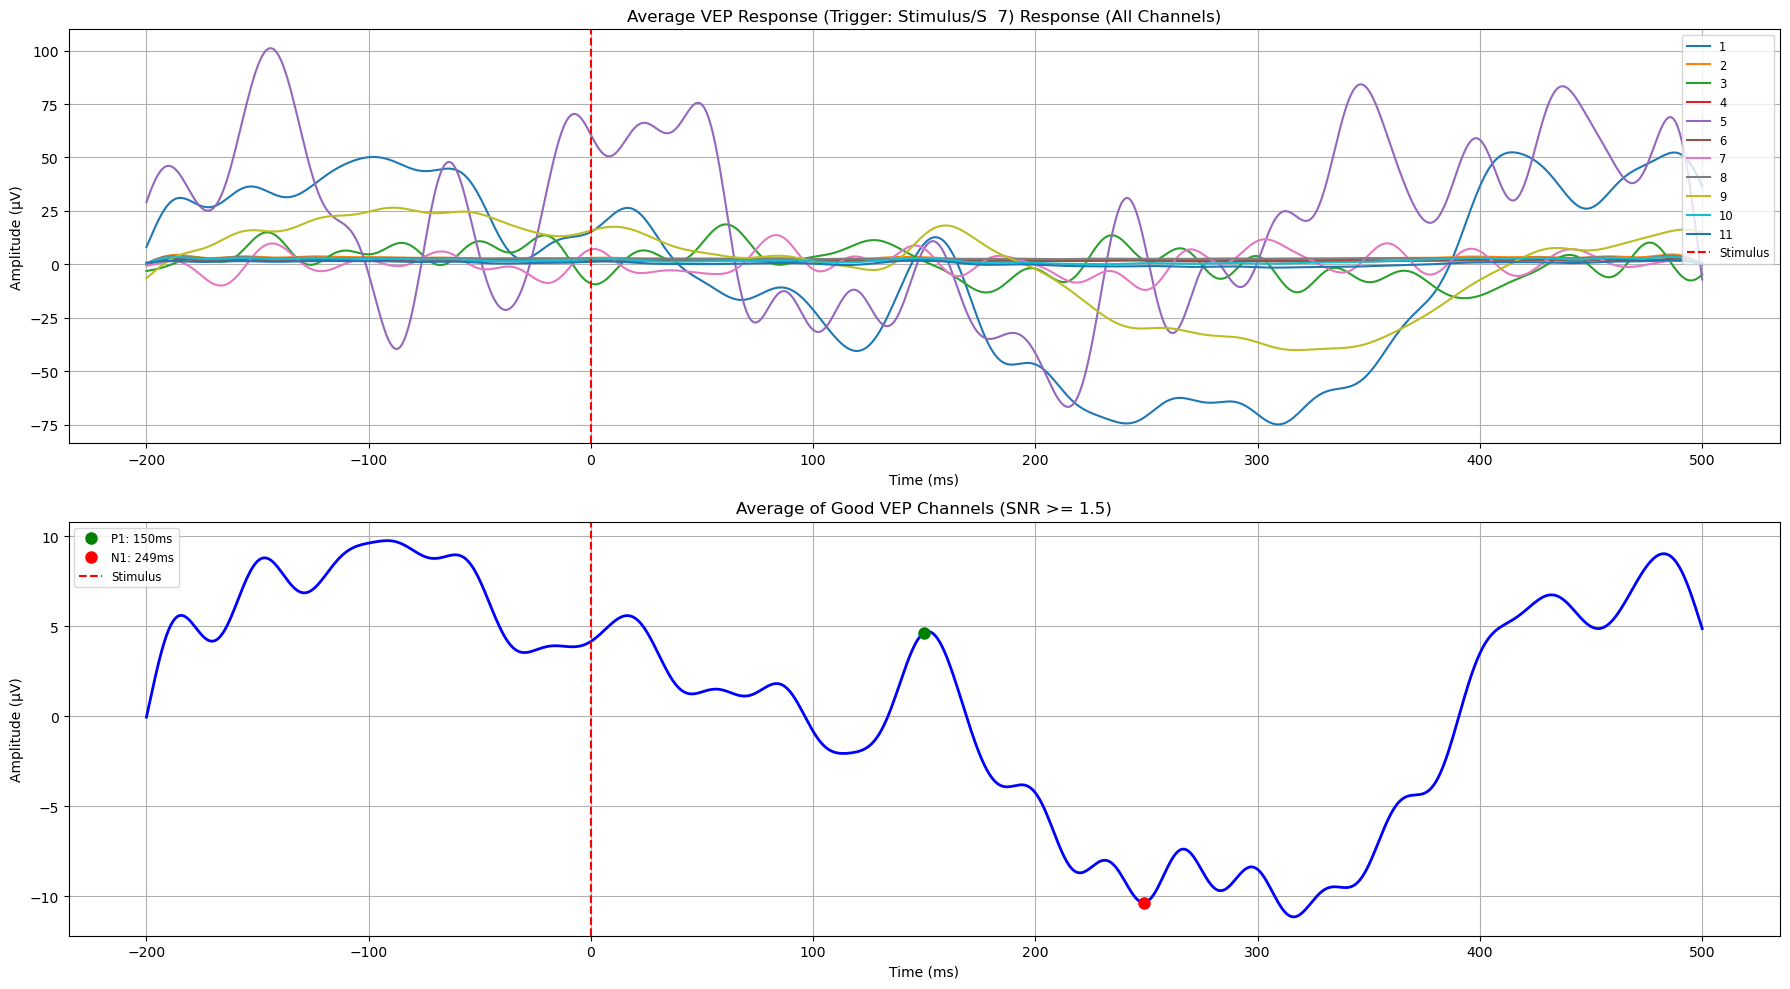

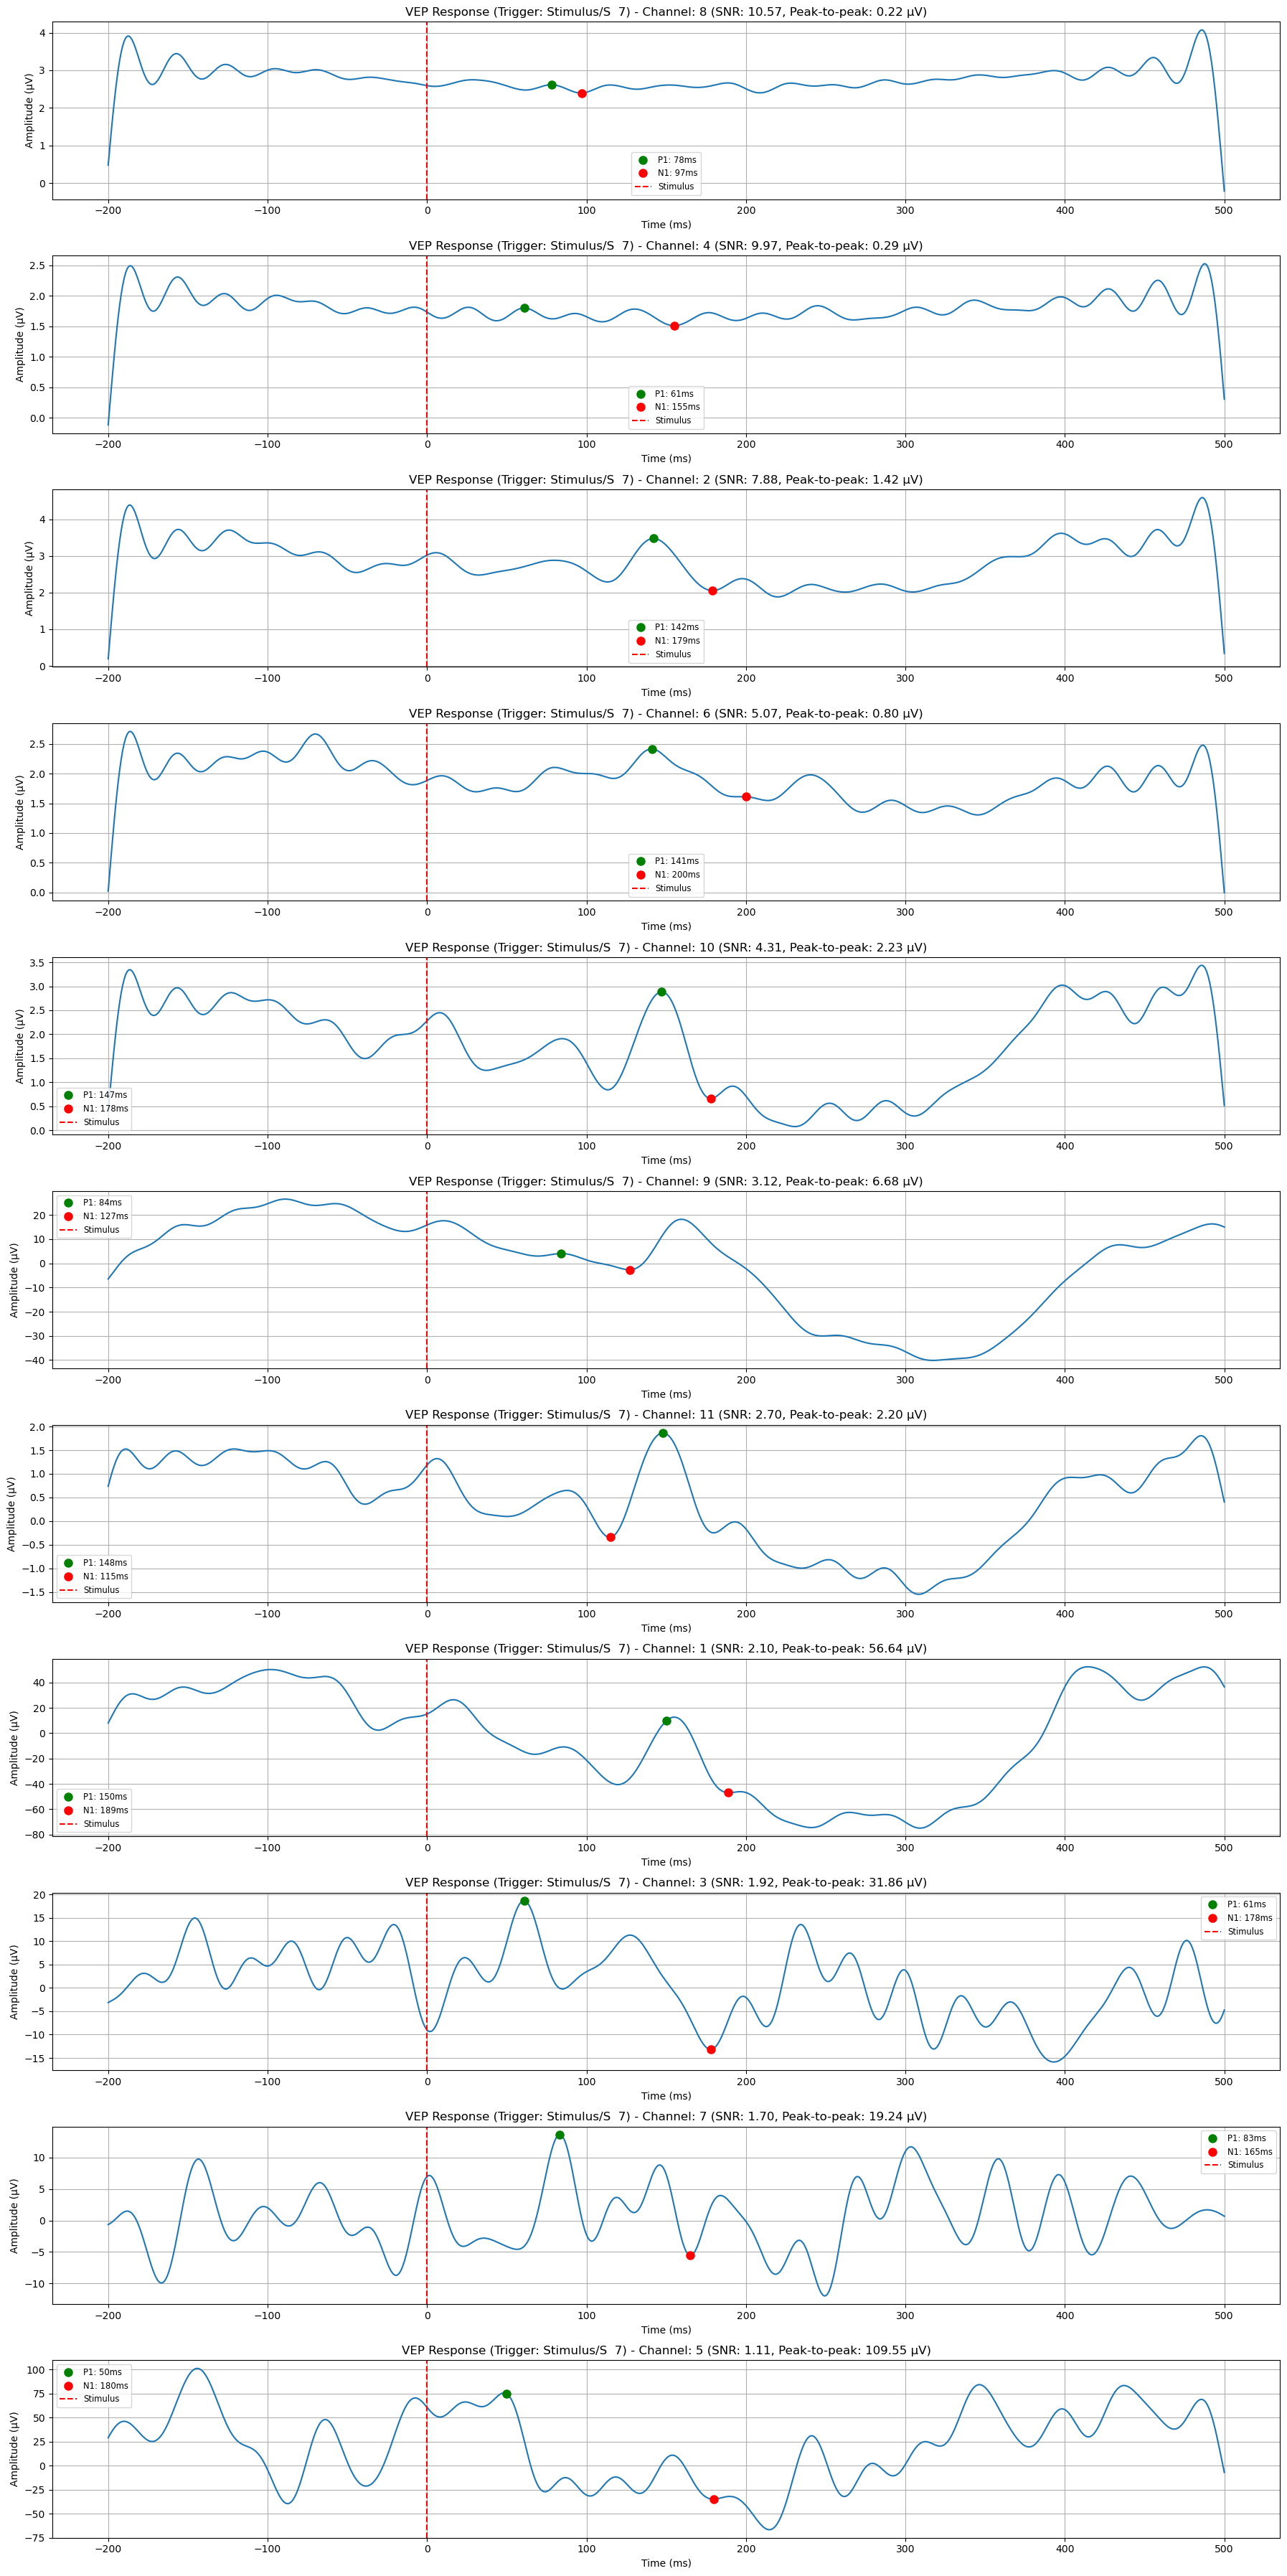

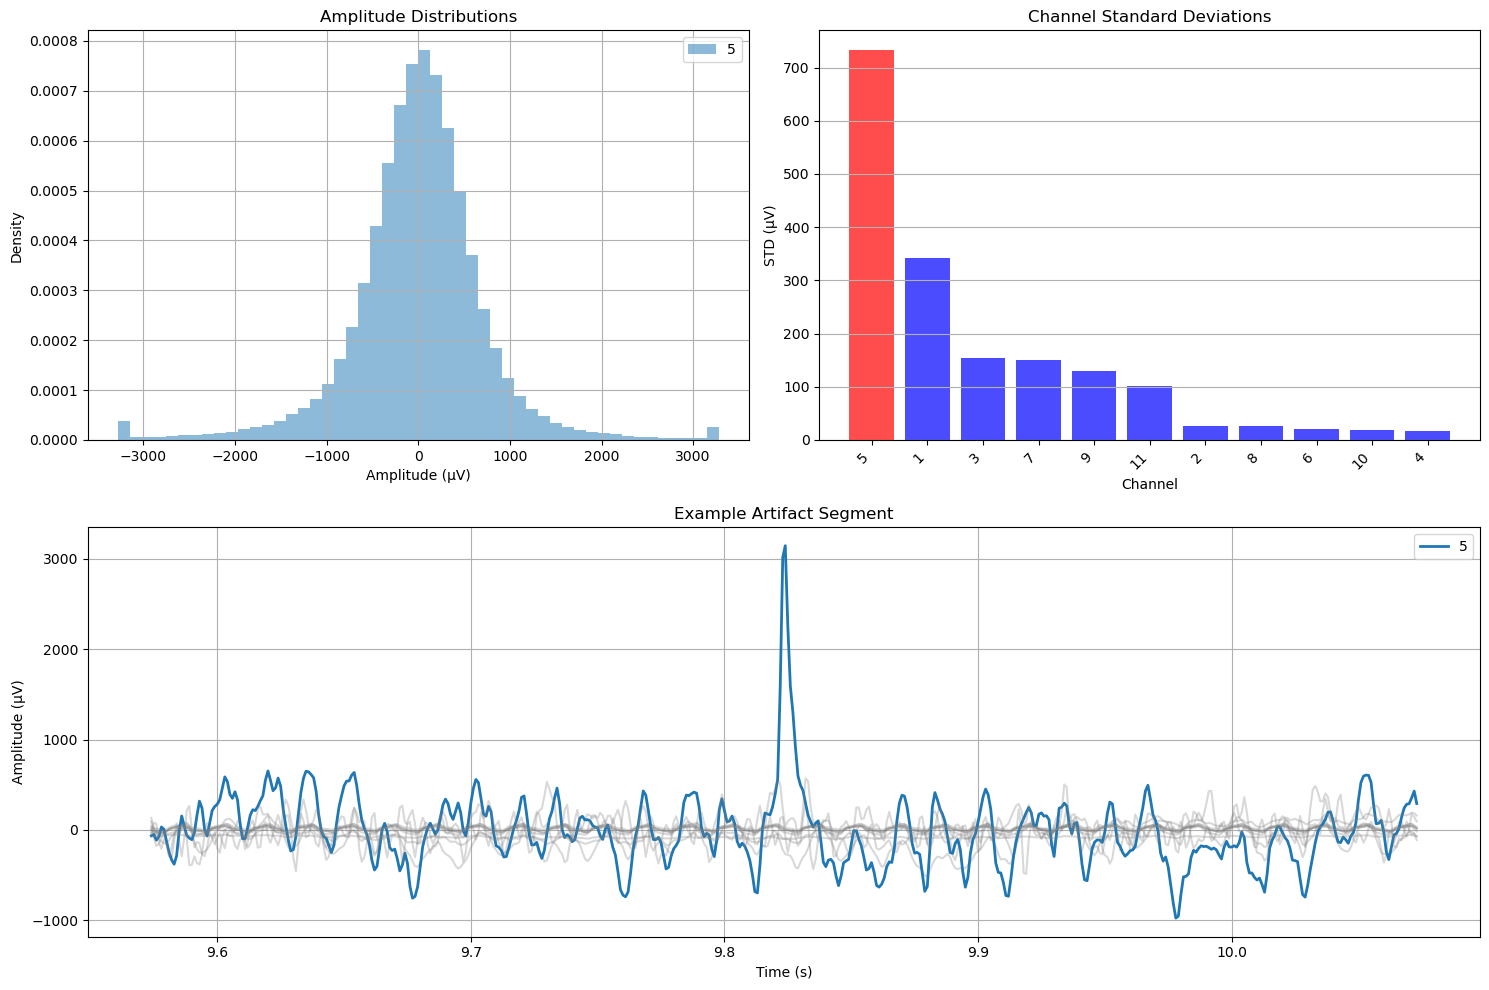

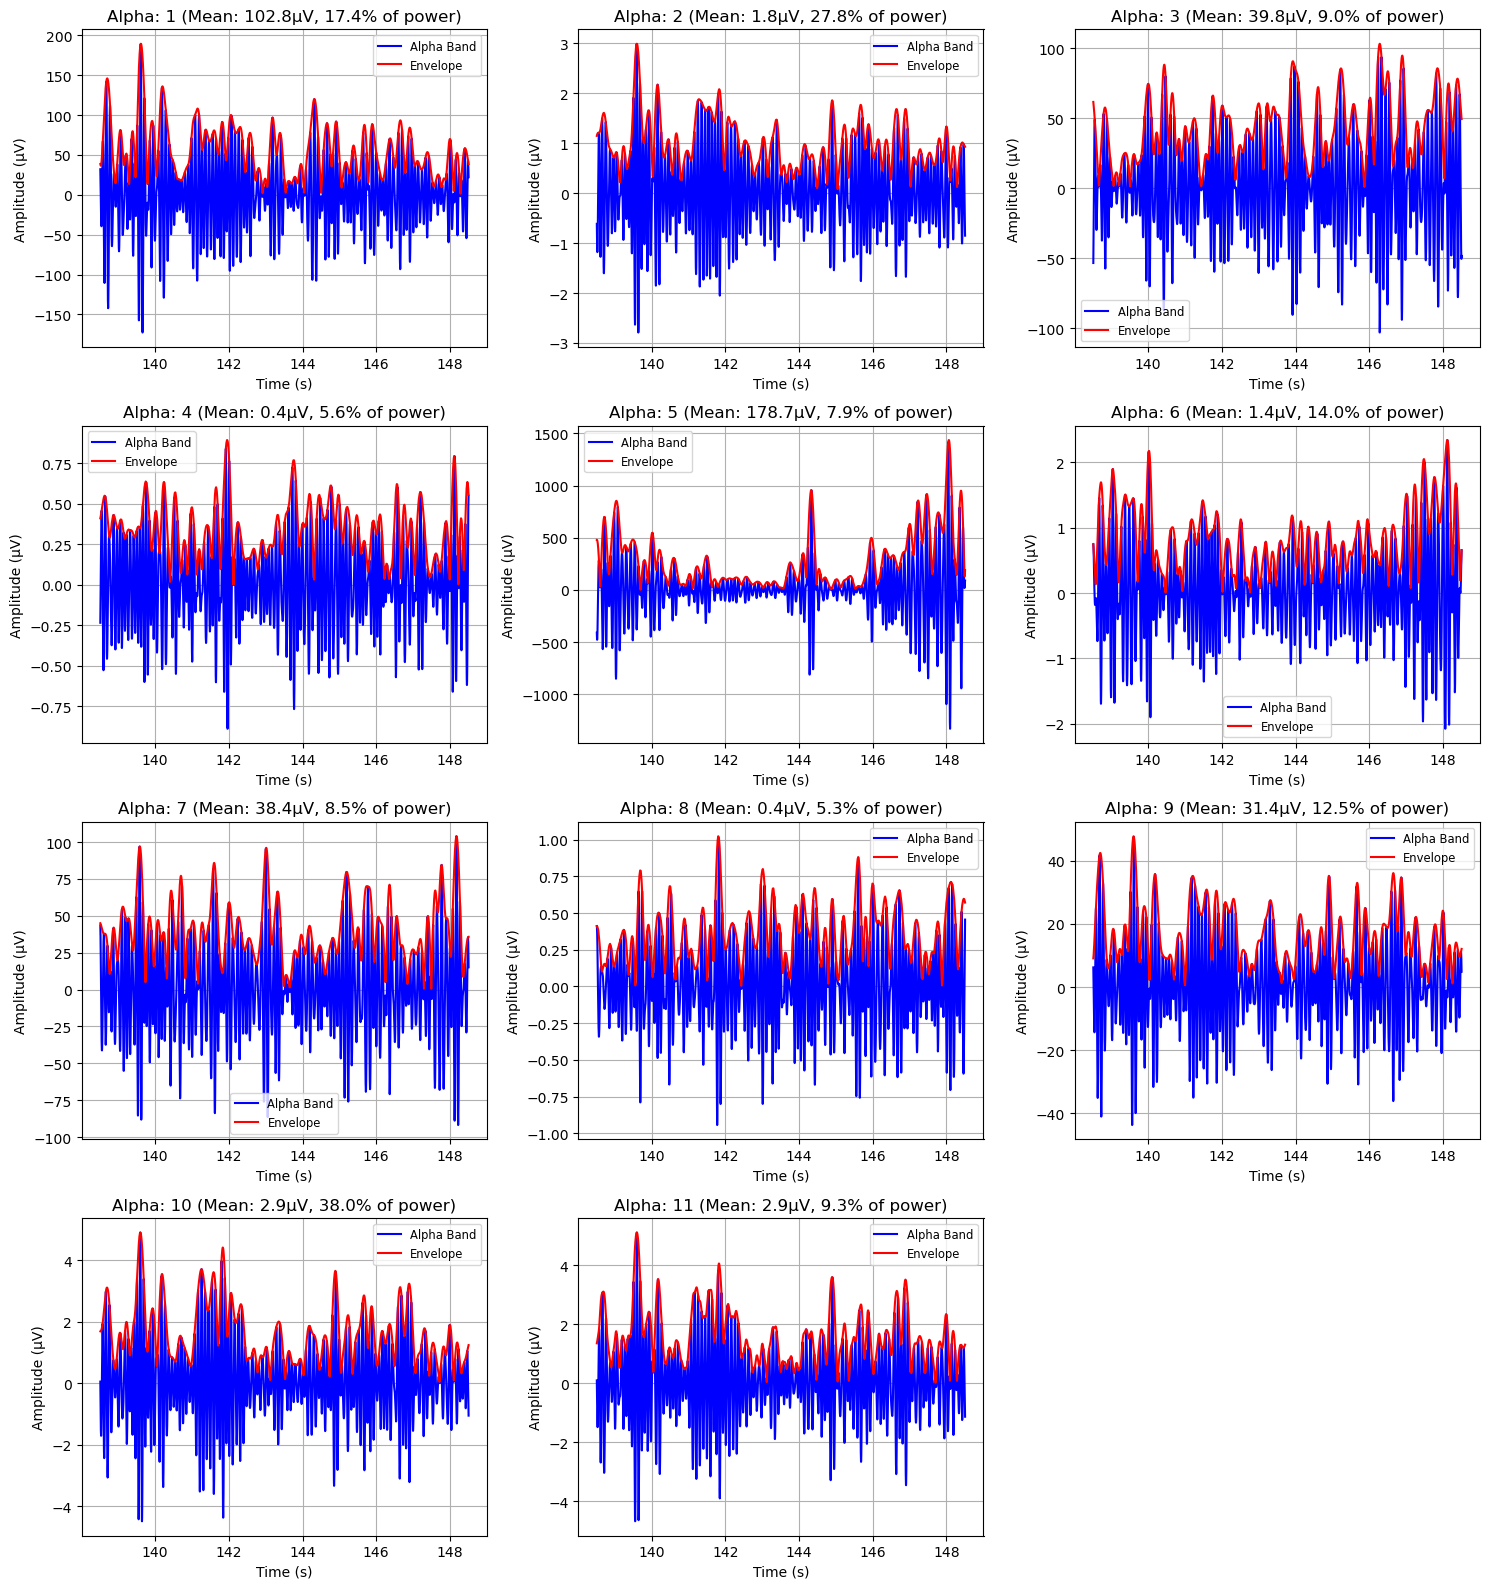

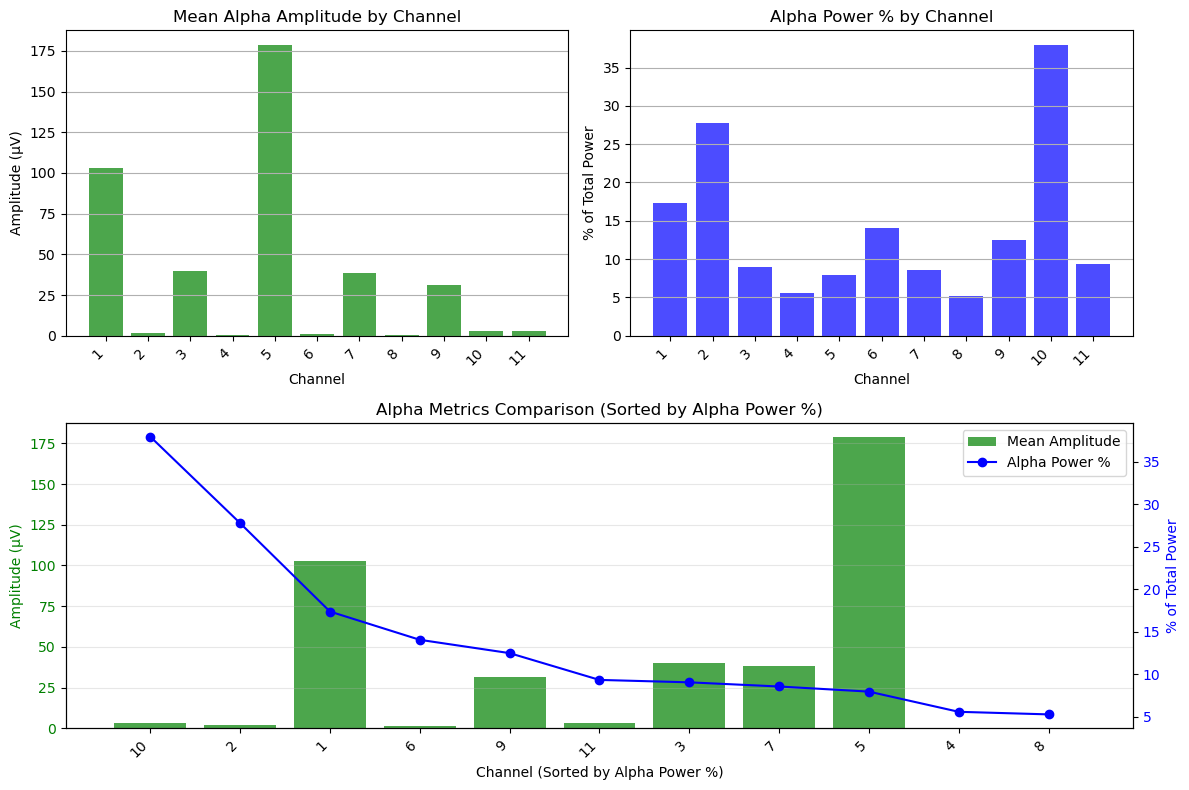

In [2]:
# -----------------------------
# File Setup and Loading
# -----------------------------
base_dir = r"Data/Test1"
#base_fname = "PF_feltTCRE_VEP_BrainAmp_5-5-2025"
#base_fname = "NS_feltTCRE_BrainAmp_5-2-2025"
#base_fname = "FD_.5sponge_4-11-2025"
base_fname = "FD_sponge1"

import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps
from matplotlib.gridspec import GridSpec
import os
import pandas as pd
import scipy.signal
from scipy.signal import find_peaks
from datetime import datetime

# Create output directory for saving results
output_dir = os.path.join(base_dir, f"{base_fname}_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
os.makedirs(output_dir, exist_ok=True)

# Load main EEG file
vhdr_file = os.path.join(base_dir, f"{base_fname}.vhdr")
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

# Find and load trigger events from marker file
events_from_annot, event_dict = mne.events_from_annotations(raw)
print(f"\n🔄 Found {len(events_from_annot)} events with {len(event_dict)} unique event types")
print(f"Event dictionary: {event_dict}")

# -----------------------------
# Identify Special Channels
# -----------------------------
# Document special electrode types
special_channels = {
    # Channel 14 is identified as a paste eEEG reference
    'paste_eeg': ['14'],
    # Add other special channels as needed
}

print(f"\n⚙️ Special Channels:")
for ch_type, ch_list in special_channels.items():
    print(f"- {ch_type}: {', '.join(ch_list)}")

# -----------------------------
# Basic EEG Info
# -----------------------------
n_channels = len(raw.ch_names)
duration_sec = raw.times[-1]
sfreq = raw.info['sfreq']
print(f"\n✅ EEG Info:")
print(f"- Channels: {n_channels}")
print(f"- Channel names: {raw.ch_names}")
print(f"- Duration: {duration_sec:.2f} sec")
print(f"- Sampling Rate: {sfreq} Hz")

# -----------------------------
# Global Amplitude / Noise
# -----------------------------
data = raw.get_data()
std = data.std()
print(f"\n📏 Global Signal STD (µV): {std * 1e6:.4f}")

# -----------------------------
# PSD Computation and Visualization
# -----------------------------
def compute_and_visualize_psd(data_obj, title_prefix="", fmax=50):
    """Compute PSD and create visualization for the input data"""
    # Check if the input is Raw or Epochs object and compute PSD accordingly
    if isinstance(data_obj, mne.io.Raw):
        # For Raw objects, use n_fft parameter
        psd = data_obj.compute_psd(fmax=fmax, n_fft=int(sfreq * 4))
    else:
        # For Epochs objects, use appropriate parameters for multitaper method
        psd = data_obj.compute_psd(fmax=fmax, method='multitaper')
    
    psds, freqs = psd.get_data(return_freqs=True)
    psds_db = 10 * np.log10(psds)
    
    # Compute band powers
    band_powers, band_relative_powers = compute_band_powers(psds, freqs)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(20, 14))
    
    # Determine how many channel plots we need
    ch_count = len(data_obj.ch_names)
    
    # Create a flexible grid layout
    # 1 row for main plot, then rows for individual channels (3 per row)
    # Calculate how many rows needed for channel plots
    channels_per_row = 3
    channel_rows = (ch_count + channels_per_row - 1) // channels_per_row
    total_rows = 1 + channel_rows  # Main plot + channel rows
    
    # Create GridSpec with proper dimensions
    gs = GridSpec(total_rows, channels_per_row, figure=fig)
    
    # 1. Main PSD plot (all channels)
    ax1 = fig.add_subplot(gs[0, :])
    for i, ch in enumerate(data_obj.ch_names):
        # Add label for special channels
        ch_label = ch
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                ch_label = f"{ch} ({ch_type})"
        
        ax1.plot(freqs, psds_db[i], label=ch_label)
    
    ax1.set_title(f"{title_prefix}Power Spectral Density (all channels)")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.set_ylabel("Power (dB µV²/Hz)")
    ax1.legend(fontsize='small', ncol=3)
    ax1.grid(True)
    
    # 2. Individual channel PSD plots
    for i, ch in enumerate(data_obj.ch_names):
        row = 1 + (i // channels_per_row)
        col = i % channels_per_row
        
        ax = fig.add_subplot(gs[row, col])
        ax.plot(freqs, psds_db[i])
        
        # Add title with special channel info if applicable
        ch_title = f"Channel: {ch}"
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                ch_title = f"Channel: {ch} ({ch_type})"
        
        ax.set_title(ch_title)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Power (dB µV²/Hz)")
        ax.axvspan(0.5, 4, color='red', alpha=0.3, label='Delta')
        ax.axvspan(4, 8, color='orange', alpha=0.3, label='Theta')
        ax.axvspan(8, 12, color='green', alpha=0.3, label='Alpha')
        ax.axvspan(12, 30, color='blue', alpha=0.3, label='Beta')
        ax.axvspan(30, 50, color='purple', alpha=0.3, label='Gamma')
        ax.legend(fontsize='x-small')
        ax.grid(True)
    
    plt.tight_layout()
    return fig, band_powers, band_relative_powers, psds, freqs

# -----------------------------
# Band Power Estimation
# -----------------------------
def compute_band_powers(psds, freqs):
    """Compute absolute and relative power in standard frequency bands"""
    def bandpower(data, freqs, band):
        idx = np.logical_and(freqs >= band[0], freqs <= band[1])
        # For each channel, calculate band power using Simpson's rule
        powers = np.zeros(data.shape[0])
        for i in range(data.shape[0]):
            powers[i] = simps(data[i, idx], freqs[idx])
        # Return the sum across all channels
        return float(np.sum(powers))  # Convert to float to avoid numpy formatting issues
    
    bands = {
        'Delta (0.5–4 Hz)': (0.5, 4),
        'Theta (4–8 Hz)': (4, 8),
        'Alpha (8–12 Hz)': (8, 12),
        'Beta (12–30 Hz)': (12, 30),
        'Gamma (30–50 Hz)': (30, 50)
    }
    
    # Calculate absolute power for each band
    band_powers = {}
    for label, band_range in bands.items():
        band_powers[label] = bandpower(psds, freqs, band_range)
    
    # Calculate total power across all bands
    total_power = sum(band_powers.values())
    
    # Calculate relative power (percentage of total)
    band_relative_powers = {}
    for label in bands.keys():
        band_relative_powers[label] = (band_powers[label] / total_power) * 100
    
    print(f"\n⚡ Band Power (total across all channels):")
    for label, power in band_powers.items():
        print(f"- {label}: {power:.8f}")
    
    print(f"\n📊 Relative Band Power (%):")
    for label, rel_power in band_relative_powers.items():
        print(f"- {label}: {rel_power:.2f}%")
    
    # SNR calculations
    snr_alpha_gamma = band_powers['Alpha (8–12 Hz)'] / band_powers['Gamma (30–50 Hz)']
    snr_alpha_beta = band_powers['Alpha (8–12 Hz)'] / band_powers['Beta (12–30 Hz)']
    print(f"\n📶 SNR Metrics:")
    print(f"- Alpha/Gamma SNR: {snr_alpha_gamma:.2f}")
    print(f"- Alpha/Beta SNR: {snr_alpha_beta:.2f}")
    
    return band_powers, band_relative_powers

# -----------------------------
# Plot Raw Data Segment
# -----------------------------
def plot_raw_segment(raw_data, duration=0.5, random=True, start_time=None):
    """Plot a segment of raw EEG data"""
    ch_count = len(raw_data.ch_names)
    data, times = raw_data[:ch_count, :]
    win = int(sfreq * duration)
    
    if random:
        start = np.random.randint(0, data.shape[1] - win)
    else:
        start = int(start_time * sfreq) if start_time is not None else 0
    
    seg = data[:, start:start+win]
    seg_time = times[start:start+win]
    
    # Dynamic offset based on signal amplitude
    max_amp = np.max(np.abs(seg)) * 1e6
    offset = max(100, max_amp * 1.5) * 1e-6  # Adjusted offset for better visualization
    
    plt.figure(figsize=(15, 8))
    for i in range(ch_count):
        # Add label for special channels
        ch_label = raw_data.ch_names[i]
        for ch_type, ch_list in special_channels.items():
            if raw_data.ch_names[i] in ch_list:
                ch_label = f"{raw_data.ch_names[i]} ({ch_type})"
        
        plt.plot(seg_time, seg[i] * 1e6 + i * offset * 1e6, label=ch_label)
    
    plt.title(f"Raw EEG ({duration}s segment {'random' if random else f'at {start_time}s'})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    
    return plt.gcf()

# -----------------------------
# Epoch Data with Artifact Rejection
# -----------------------------
def create_clean_epochs(raw, events, event_id, tmin=-0.2, tmax=0.5, reject_threshold_mv=5):
    """Create epochs from raw data and reject artifacts above threshold"""
    
    # Set rejection threshold (converting from mV to V)
    reject_criteria = dict(eeg=reject_threshold_mv * 1e-3)  # 5 mV converted to V
    
    # Create epochs with rejection
    epochs = mne.Epochs(raw, events, event_id, tmin=tmin, tmax=tmax,
                        baseline=(tmin, 0), reject=reject_criteria,
                        preload=True, verbose=True)
    
    # Get information about dropped epochs
    drop_log = epochs.drop_log
    total_epochs = len(events)
    kept_epochs = len(epochs)
    dropped_epochs = total_epochs - kept_epochs
    drop_percent = (dropped_epochs / total_epochs) * 100 if total_epochs > 0 else 0
    
    print(f"\n🧹 Artifact Rejection:")
    print(f"- Total epochs: {total_epochs}")
    print(f"- Kept epochs: {kept_epochs}")
    print(f"- Rejected epochs: {dropped_epochs} ({drop_percent:.1f}%)")
    
    # Identify which channels had the most artifacts
    if dropped_epochs > 0:
        channel_drops = {}
        for ch in raw.ch_names:
            channel_drops[ch] = 0
        
        for log in drop_log:
            if log and len(log) > 0:
                for reason in log:
                    if reason != 'eeg' and reason in raw.ch_names:
                        channel_drops[reason] = channel_drops.get(reason, 0) + 1
        
        print("- Rejection count by channel:")
        for ch, count in channel_drops.items():
            if count > 0:
                print(f"  * {ch}: {count} epochs")
        
        # Additional analysis of problem channels
        if channel_drops:
            problem_channels = sorted(
                [(ch, count) for ch, count in channel_drops.items() if count > 0],
                key=lambda x: x[1], reverse=True
            )
            if problem_channels:
                worst_ch, worst_count = problem_channels[0]
                worst_percent = (worst_count / total_epochs) * 100
                print(f"\n⚠️ Channel Quality Alert:")
                print(f"- Most problematic channel: {worst_ch} with {worst_count} rejected epochs ({worst_percent:.1f}%)")
                
                # Get some data about the worst channel
                ch_idx = raw.ch_names.index(worst_ch)
                ch_data = raw.get_data()[ch_idx] * 1e6  # Convert to µV
                ch_std = np.std(ch_data)
                ch_max = np.max(np.abs(ch_data))
                print(f"- Channel '{worst_ch}' stats: Max amplitude: {ch_max:.2f} µV, STD: {ch_std:.2f} µV")
    
    return epochs

# -----------------------------
# Improved VEP Processing and Visualization
# -----------------------------
def process_vep_response(epochs, title="Visual Evoked Potential", min_snr=1.5, max_latency=250):
    """
    Compute average evoked response and visualize all channels with improved VEP detection
    
    Parameters:
    -----------
    epochs : mne.Epochs
        Epochs object containing the data
    title : str
        Title for the plots
    min_snr : float
        Minimum signal-to-noise ratio for a channel to be considered as having good signal quality
    max_latency : float
        Maximum latency (in ms) for identifying peaks (P1, N1 components)
    """
    # Apply additional filtering specific to VEP analysis (1-30 Hz)
    epochs_vep = epochs.copy().filter(1, 30, method='fir')
    
    # Calculate evoked response (average across epochs)
    evoked = epochs_vep.average()
    
    times = evoked.times * 1000  # Convert to milliseconds
    data = evoked.data * 1e6  # Convert to µV
    
    # Pre-stimulus baseline period for noise estimation
    baseline_idx = np.where((times >= -100) & (times < 0))[0]
    baseline_std = np.std(data[:, baseline_idx], axis=1)
    
    # Post-stimulus analysis window
    post_stim_idx = np.where((times >= 0) & (times <= max_latency))[0]
    
    # Calculate signal quality metrics for each channel
    channel_metrics = []
    
    # For peak detection
    peak_window_p1 = (50, 150)  # Typical P1 latency (ms)
    peak_window_n1 = (75, 200)  # Typical N1 latency (ms)
    
    for i, ch in enumerate(evoked.ch_names):
        if len(post_stim_idx) > 0:
            ch_data = data[i, post_stim_idx]
            ch_times = times[post_stim_idx]
            
            # Calculate signal-to-noise ratio
            ch_std = baseline_std[i]
            snr = np.max(np.abs(ch_data)) / (2 * ch_std) if ch_std > 0 else 0
            
            # Find P1 (positive peak)
            p1_window = np.where((ch_times >= peak_window_p1[0]) & (ch_times <= peak_window_p1[1]))[0]
            if len(p1_window) > 0:
                # Add small buffer to ensure we're finding a real peak
                p1_data = ch_data[p1_window]
                peaks, _ = find_peaks(p1_data, height=0, distance=10)  # Find positive peaks
                
                if len(peaks) > 0:
                    # Choose the highest peak in the window
                    p1_peak_idx = peaks[np.argmax(p1_data[peaks])]
                    p1_idx = p1_window[0] + p1_peak_idx
                    p1_time = ch_times[p1_idx]
                    p1_amp = ch_data[p1_idx]
                else:
                    # If no clear peak found, use the maximum point
                    p1_idx = p1_window[0] + np.argmax(p1_data)
                    p1_time = ch_times[p1_idx]
                    p1_amp = ch_data[p1_idx]
            else:
                # Fallback if window is empty
                p1_idx = None
                p1_time = None
                p1_amp = None
                
            # Find N1 (negative peak after P1)
            n1_window = np.where((ch_times >= peak_window_n1[0]) & (ch_times <= peak_window_n1[1]))[0]
            if len(n1_window) > 0:
                n1_data = ch_data[n1_window]
                troughs, _ = find_peaks(-n1_data, height=0, distance=10)  # Find negative peaks (troughs)
                
                if len(troughs) > 0:
                    # Choose the deepest trough
                    n1_peak_idx = troughs[np.argmax(-n1_data[troughs])]
                    n1_idx = n1_window[0] + n1_peak_idx
                    n1_time = ch_times[n1_idx]
                    n1_amp = ch_data[n1_idx]
                else:
                    # If no clear trough found, use the minimum point
                    n1_idx = n1_window[0] + np.argmin(n1_data)
                    n1_time = ch_times[n1_idx]
                    n1_amp = ch_data[n1_idx]
            else:
                # Fallback if window is empty
                n1_idx = None
                n1_time = None
                n1_amp = None
            
            # Calculate peak-to-peak amplitude if both P1 and N1 are found
            if p1_amp is not None and n1_amp is not None:
                peak_to_peak = p1_amp - n1_amp
            else:
                # Fallback - use min/max in the entire post-stimulus window
                peak_to_peak = np.max(ch_data) - np.min(ch_data)
            
            # Store all metrics
            channel_metrics.append({
                'index': i,
                'name': ch,
                'peak_to_peak': peak_to_peak,
                'snr': snr,
                'p1_time': p1_time,
                'n1_time': n1_time,
                'p1_idx': p1_idx,
                'n1_idx': n1_idx,
                'p1_amp': p1_amp,
                'n1_amp': n1_amp
            })
    
    # Sort channels by SNR
    channel_metrics.sort(key=lambda x: x['snr'], reverse=True)
    
    # Select channels with good signal (above minimum SNR)
    good_channels = [ch for ch in channel_metrics if ch['snr'] >= min_snr]
    
    # If no good channels found, include at least the top channel
    if not good_channels and channel_metrics:
        good_channels = [channel_metrics[0]]
    
    # Print the selected channels
    ch_count = len(good_channels)
    print(f"\n📊 VEP Analysis Result:")
    print(f"- Found {ch_count} channels with good VEP signal (SNR >= {min_snr})")
    
    for ch in good_channels:
        p1_info = f"P1: {ch['p1_time']:.1f}ms, {ch['p1_amp']:.2f}µV" if ch['p1_time'] is not None else "P1: Not detected"
        n1_info = f"N1: {ch['n1_time']:.1f}ms, {ch['n1_amp']:.2f}µV" if ch['n1_time'] is not None else "N1: Not detected"
        print(f"- {ch['name']}: Peak-to-peak: {ch['peak_to_peak']:.2f}µV, SNR: {ch['snr']:.2f}, {p1_info}, {n1_info}")
    
    # Also print info on channels below threshold
    excluded_channels = [ch for ch in channel_metrics if ch not in good_channels]
    if excluded_channels:
        print(f"\n- Channels below SNR threshold of {min_snr}:")
        for ch in excluded_channels:
            print(f"  * {ch['name']}: SNR = {ch['snr']:.2f}")
    
    # Create figure for all channels
    fig_all = plt.figure(figsize=(18, 10))
    
    # Plot the average across all channels
    plt.subplot(2, 1, 1)
    for i, ch in enumerate(evoked.ch_names):
        # Add label for special channels
        ch_label = ch
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                ch_label = f"{ch} ({ch_type})"
        
        plt.plot(times, data[i], label=ch_label)
    
    plt.title(f"Average {title} Response (All Channels)")
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.axvline(x=0, color='r', linestyle='--', label='Stimulus')
    plt.legend(fontsize='small', loc='upper right')
    plt.grid(True)
    
    # Plot average of good channels
    plt.subplot(2, 1, 2)
    good_indices = [ch['index'] for ch in good_channels]
    if good_indices:
        avg_good = np.mean(data[good_indices, :], axis=0)
        plt.plot(times, avg_good, 'b', linewidth=2)
        
        # Mark typical VEP components
        # Find P1 component (typically around 100ms)
        p1_window = np.where((times >= 50) & (times <= 150))[0]
        if len(p1_window) > 0:
            p1_idx = p1_window[0] + np.argmax(avg_good[p1_window])
            p1_time = times[p1_idx]
            p1_amp = avg_good[p1_idx]
            plt.plot(p1_time, p1_amp, 'go', markersize=8, label=f'P1: {p1_time:.0f}ms')
            
        # Find N1 component (typically around 170ms)
        n1_window = np.where((times >= 150) & (times <= 250))[0]
        if len(n1_window) > 0:
            n1_idx = n1_window[0] + np.argmin(avg_good[n1_window])
            n1_time = times[n1_idx]
            n1_amp = avg_good[n1_idx]
            plt.plot(n1_time, n1_amp, 'ro', markersize=8, label=f'N1: {n1_time:.0f}ms')
            
        plt.title(f"Average of Good VEP Channels (SNR >= {min_snr})")
    else:
        plt.text(0.5, 0.5, 'No channels met SNR criteria', 
                 horizontalalignment='center', verticalalignment='center')
        plt.title("No Good VEP Channels Found")
        
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude (µV)")
    plt.axvline(x=0, color='r', linestyle='--', label='Stimulus')
    plt.legend(fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    
    # Create a separate figure for individual channel plots
    fig_channels = plt.figure(figsize=(18, 3 * (len(channel_metrics) + 1)))
    
    # Plot individual channels (all channels, not just good ones)
    for idx, ch_metric in enumerate(channel_metrics):
        i = ch_metric['index']
        ch = ch_metric['name']
        
        plt.subplot(len(channel_metrics), 1, idx+1)
        plt.plot(times, data[i])
        
        # Add title with metrics
        ch_title = f"{title} - Channel: {ch}"
        # Add special channel type if applicable
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                ch_title = f"{title} - Channel: {ch} ({ch_type})"
                
        ch_title += f" (SNR: {ch_metric['snr']:.2f}, Peak-to-peak: {ch_metric['peak_to_peak']:.2f} µV)"
        plt.title(ch_title)
        
        # Mark P1 component
        if ch_metric['p1_time'] is not None:
            plt.plot(ch_metric['p1_time'], ch_metric['p1_amp'], 'go', markersize=8, 
                   label=f'P1: {ch_metric["p1_time"]:.0f}ms')
        
        # Mark N1 component
        if ch_metric['n1_time'] is not None:
            plt.plot(ch_metric['n1_time'], ch_metric['n1_amp'], 'ro', markersize=8, 
                   label=f'N1: {ch_metric["n1_time"]:.0f}ms')
        
        plt.axvline(x=0, color='r', linestyle='--', label='Stimulus')
        plt.xlabel("Time (ms)")
        plt.ylabel("Amplitude (µV)")
        plt.grid(True)
        plt.legend(fontsize='small')
    
    plt.tight_layout()
    
    return fig_all, fig_channels, evoked, good_channels

# -----------------------------
# Alpha Wave Analysis
# -----------------------------
def analyze_alpha_waves(raw):
    """Analyze alpha wave characteristics in the data"""
    # Filter data to alpha band (8-12 Hz)
    raw_alpha = raw.copy().filter(8, 12)
    
    # Get data
    alpha_data = raw_alpha.get_data() * 1e6  # convert to µV
    
    # Calculate alpha amplitude envelope using Hilbert transform
    alpha_envelope = np.abs(scipy.signal.hilbert(alpha_data, axis=1))
    
    # Calculate metrics
    alpha_mean = np.mean(alpha_envelope, axis=1)
    alpha_std = np.std(alpha_envelope, axis=1)
    alpha_max = np.max(alpha_envelope, axis=1)
    
    # Create visualization with horizontal arrangement for better space usage
    ch_count = len(raw.ch_names)
    
    # Calculate grid dimensions
    cols = min(3, ch_count)
    rows = (ch_count + cols - 1) // cols
    
    fig = plt.figure(figsize=(5*cols, 4*rows))
    gs = GridSpec(rows, cols, figure=fig)
    
    # Create alpha metrics table
    metrics_df = pd.DataFrame({
        'Channel': raw.ch_names,
        'Mean Amplitude (µV)': alpha_mean,
        'Max Amplitude (µV)': alpha_max,
        'Std Dev (µV)': alpha_std,
    })
    
    # Additional metrics: alpha power ratio
    # Compute proportion of alpha to total power
    psd = raw.compute_psd(fmax=50)
    psds, freqs = psd.get_data(return_freqs=True)
    
    alpha_ratios = []
    
    for ch_idx in range(len(raw.ch_names)):
        # Get alpha band indices
        alpha_idx = np.logical_and(freqs >= 8, freqs <= 12)
        alpha_power = simps(psds[ch_idx, alpha_idx], freqs[alpha_idx])
        
        # Get total power (0.5-50 Hz)
        total_idx = np.logical_and(freqs >= 0.5, freqs <= 50)
        total_power = simps(psds[ch_idx, total_idx], freqs[total_idx])
        
        # Calculate ratio
        alpha_ratio = (alpha_power / total_power) * 100
        alpha_ratios.append(alpha_ratio)
    
    # Add to dataframe
    metrics_df['Alpha Power (%)'] = alpha_ratios
    
    # Add special channel info
    special_ch_info = []
    for ch in raw.ch_names:
        info = []
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                info.append(ch_type)
        special_ch_info.append(', '.join(info) if info else '')
    
    metrics_df['Channel Type'] = special_ch_info
    
    # Sort channels by alpha power ratio for analysis
    sorted_metrics = metrics_df.sort_values(by='Alpha Power (%)', ascending=False)
    
    print("\n🧠 Alpha Wave Metrics (Sorted by Alpha Power %):")
    print(sorted_metrics.to_string(index=False))
    
    # Plot alpha waves and envelopes
    for i, ch in enumerate(raw.ch_names):
        row = i // cols
        col = i % cols
        
        ax = fig.add_subplot(gs[row, col])
        
        # Plot 10 seconds of alpha signal and its envelope
        t_start = int(raw.times.shape[0] * 0.3)  # Start at 30% into recording
        segment_len = min(int(10 * sfreq), len(raw.times) - t_start)  # Handle case where recording is short
        t_end = t_start + segment_len
        
        t_plot = raw.times[t_start:t_end]
        ax.plot(t_plot, alpha_data[i, t_start:t_end], 'b', label='Alpha Band')
        ax.plot(t_plot, alpha_envelope[i, t_start:t_end], 'r', label='Envelope')
        
        # Add alpha metrics to the title
        ch_alpha_ratio = metrics_df.loc[metrics_df['Channel'] == ch, 'Alpha Power (%)'].values[0]
        
        # Add special channel info if applicable
        ch_title = f"Alpha: {ch}"
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                ch_title = f"Alpha: {ch} ({ch_type})"
        
        ch_title += f" (Mean: {alpha_mean[i]:.1f}µV, {ch_alpha_ratio:.1f}% of power)"
        ax.set_title(ch_title)
        
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude (µV)")
        ax.legend(fontsize='small')
        ax.grid(True)
    
    plt.tight_layout()
    
    # Create a detailed alpha summary figure
    summary_fig = plt.figure(figsize=(12, 8))
    summary_gs = GridSpec(2, 2, figure=summary_fig)
    
    # 1. Bar chart of mean alpha amplitudes
    ax1 = summary_fig.add_subplot(summary_gs[0, 0])
    bars = ax1.bar(raw.ch_names, alpha_mean, color='green', alpha=0.7)
    
    # Highlight special channels
    for i, ch in enumerate(raw.ch_names):
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                bars[i].set_color('red')
                bars[i].set_alpha(0.5)
    
    ax1.set_title('Mean Alpha Amplitude by Channel')
    ax1.set_xlabel('Channel')
    ax1.set_ylabel('Amplitude (µV)')
    plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')
    ax1.grid(True, axis='y')
    
    # 2. Bar chart of alpha power percentages
    ax2 = summary_fig.add_subplot(summary_gs[0, 1])
    bars = ax2.bar(raw.ch_names, alpha_ratios, color='blue', alpha=0.7)
    
    # Highlight special channels
    for i, ch in enumerate(raw.ch_names):
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                bars[i].set_color('red')
                bars[i].set_alpha(0.5)
    
    ax2.set_title('Alpha Power % by Channel')
    ax2.set_xlabel('Channel')
    ax2.set_ylabel('% of Total Power')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.grid(True, axis='y')
    
    # 3. Topographic-style plot (simplified version)
    ax3 = summary_fig.add_subplot(summary_gs[1, :])
    # Create a horizontal plot showing channel comparisons
    sorted_idx = np.argsort(alpha_ratios)[::-1]  # Sort by alpha ratio descending
    ch_names_sorted = [raw.ch_names[i] for i in sorted_idx]
    alpha_mean_sorted = [alpha_mean[i] for i in sorted_idx]
    alpha_ratios_sorted = [alpha_ratios[i] for i in sorted_idx]
    
    # Plot bars with dual y-axis
    bars = ax3.bar(ch_names_sorted, alpha_mean_sorted, color='green', alpha=0.7, label='Mean Amplitude')
    
    # Highlight special channels
    for i, ch in enumerate(ch_names_sorted):
        for ch_type, ch_list in special_channels.items():
            if ch in ch_list:
                bars[i].set_color('red')
                bars[i].set_alpha(0.5)
    
    ax3.set_xlabel('Channel (Sorted by Alpha Power %)')
    ax3.set_ylabel('Amplitude (µV)', color='green')
    ax3.tick_params(axis='y', labelcolor='green')
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
    
    # Second y-axis for alpha ratios
    ax3b = ax3.twinx()
    ax3b.plot(ch_names_sorted, alpha_ratios_sorted, 'bo-', label='Alpha Power %')
    ax3b.set_ylabel('% of Total Power', color='blue')
    ax3b.tick_params(axis='y', labelcolor='blue')
    
    # Add title and grid
    ax3.set_title('Alpha Metrics Comparison (Sorted by Alpha Power %)')
    ax3.grid(True, axis='y', alpha=0.3)
    
    # Add combined legend
    lines, labels = ax3.get_legend_handles_labels()
    lines2, labels2 = ax3b.get_legend_handles_labels()
    ax3b.legend(lines + lines2, labels + labels2, loc='upper right')
    
    plt.tight_layout()
    
    return fig, summary_fig, sorted_metrics

# -----------------------------
# Additional Analyses for Artifact Identification
# -----------------------------
def analyze_problematic_channels(raw, problem_channels=None):
    """Analyze channels with high artifact rates to identify issues"""
    if not problem_channels:
        # If no specific channels provided, analyze all
        problem_channels = raw.ch_names
    
    # Create figure for analysis
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 2, figure=fig)
    
    # 1. Amplitude distributions
    ax1 = fig.add_subplot(gs[0, 0])
    data = raw.get_data() * 1e6  # µV
    
    for i, ch in enumerate(raw.ch_names):
        if ch in problem_channels:
            # Plot histogram of amplitude values
            ax1.hist(data[i], bins=50, alpha=0.5, label=ch, density=True)
    
    ax1.set_title('Amplitude Distributions')
    ax1.set_xlabel('Amplitude (µV)')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True)
    
    # 2. Standard deviations
    ax2 = fig.add_subplot(gs[0, 1])
    stds = np.std(data, axis=1)
    
    # Sort channels by std
    std_order = np.argsort(stds)[::-1]
    sorted_chs = [raw.ch_names[i] for i in std_order]
    sorted_stds = [stds[i] for i in std_order]
    
    # Color bars based on whether they're in problem_channels
    colors = ['red' if ch in problem_channels else 'blue' for ch in sorted_chs]
    
    ax2.bar(sorted_chs, sorted_stds, color=colors, alpha=0.7)
    ax2.set_title('Channel Standard Deviations')
    ax2.set_xlabel('Channel')
    ax2.set_ylabel('STD (µV)')
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.grid(True, axis='y')
    
    # 3. Artifact examples
    ax3 = fig.add_subplot(gs[1, :])
    
    # Find segments with high amplitude in problem channels
    artifact_samples = []
    channel_indices = [raw.ch_names.index(ch) for ch in problem_channels if ch in raw.ch_names]
    
    # Define threshold as 4 standard deviations
    thresholds = [4 * np.std(data[i]) for i in channel_indices]
    
    # Find segments where any problem channel exceeds its threshold
    for i, ch_idx in enumerate(channel_indices):
        # Find where channel exceeds threshold
        threshold = thresholds[i]
        exceeds = np.where(np.abs(data[ch_idx]) > threshold)[0]
        
        if len(exceeds) > 0:
            # Find segments (continuous blocks of samples)
            diffs = np.diff(exceeds)
            break_points = np.where(diffs > 1)[0] + 1
            segments = np.split(exceeds, break_points)
            
            # Take the middle sample of each segment
            for segment in segments:
                if len(segment) > 0:
                    middle = segment[len(segment) // 2]
                    artifact_samples.append(middle)
    
    # Plot a sample artifact if found
    if artifact_samples:
        # Use the first artifact found
        center = artifact_samples[0]
        window = int(sfreq * 0.5)  # 0.5 second window
        start = max(0, center - window//2)
        end = min(data.shape[1], center + window//2)
        
        t = raw.times[start:end]
        
        # Plot all channels with problem channels highlighted
        for i, ch in enumerate(raw.ch_names):
            if ch in problem_channels:
                ax3.plot(t, data[i, start:end], linewidth=2, label=ch)
            else:
                ax3.plot(t, data[i, start:end], 'gray', alpha=0.3)
        
        ax3.set_title('Example Artifact Segment')
        ax3.set_xlabel('Time (s)')
        ax3.set_ylabel('Amplitude (µV)')
        ax3.legend()
        ax3.grid(True)
    else:
        ax3.text(0.5, 0.5, 'No clear artifacts detected with current threshold',
                horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    return fig

# -----------------------------
# Save results to report file
# -----------------------------
def create_report(output_dir, base_fname, metrics):
    """Create a detailed report file with all analysis results"""
    report_path = os.path.join(output_dir, f"{base_fname}_report.md")
    
    with open(report_path, 'w') as f:
        f.write(f"# EEG Analysis Report: {base_fname}\n")
        f.write(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("## Signal Quality Metrics\n")
        for key, value in metrics.items():
            f.write(f"- **{key}**: {value}\n")
            
        f.write("\n## Special Channels\n")
        for ch_type, ch_list in special_channels.items():
            f.write(f"- **{ch_type}**: {', '.join(ch_list)}\n")
            
        f.write("\n## Notes\n")
        f.write("- VEP analysis performed with improved peak detection algorithm\n")
        f.write("- All channels included in the VEP analysis\n")
        f.write("- Special channel types noted in all visualizations\n")
        
    print(f"\n📝 Report created: {report_path}")
    return report_path

# -----------------------------
# MAIN ANALYSIS PIPELINE
# -----------------------------

try:
    # Collection of metrics for report
    analysis_metrics = {}
    
    # 1. Run continuous data analysis
    print("\n========== CONTINUOUS EEG ANALYSIS ==========")
    # Plot a random raw segment
    raw_fig = plot_raw_segment(raw, duration=1.0)  # Increased from 0.5s to 1.0s for better visualization
    raw_fig.savefig(os.path.join(output_dir, f"{base_fname}_raw_segment.png"), dpi=300)

    # Compute PSD and band powers for continuous data
    psd_fig, band_powers, band_rel_powers, psds_data, freqs_data = compute_and_visualize_psd(raw, "Continuous EEG: ")
    psd_fig.savefig(os.path.join(output_dir, f"{base_fname}_continuous_psd.png"), dpi=300)
    
    # Save band powers to metrics
    for band, power in band_rel_powers.items():
        analysis_metrics[f"Relative {band}"] = f"{power:.2f}%"
    
    analysis_metrics["Global Signal STD (µV)"] = f"{std * 1e6:.4f}"

    # 2. Process VEP epochs with artifact rejection
    print("\n========== VEP ANALYSIS WITH ARTIFACT REJECTION ==========")

    # Look specifically for visual stimulus triggers (likely to start with 'S')
    # Using 'Stimulus/' prefix based on the event dictionary seen in the output
    trigger_keys = [key for key in event_dict.keys() if 'Stimulus/' in key]
    
    if trigger_keys:
        # If you have specific trigger you want to use, select it here
        selected_trigger = trigger_keys[0]  # Using the first trigger type
        trigger_id = {selected_trigger: event_dict[selected_trigger]}
        
        print(f"\n🔍 Processing epochs for trigger: {selected_trigger}")
        
        # Create epochs with artifact rejection
        vep_epochs = create_clean_epochs(raw, events_from_annot, trigger_id, 
                                         tmin=-0.2, tmax=0.5, reject_threshold_mv=5)
        
        # Save rejection rate to metrics
        analysis_metrics["Artifact Rejection Rate"] = f"{(1 - len(vep_epochs)/len(events_from_annot))*100:.1f}%"
        
        if len(vep_epochs) > 0:
            # Calculate and plot evoked response with improved VEP detection
            vep_fig_all, vep_fig_channels, evoked_data, good_vep_channels = process_vep_response(
                vep_epochs, title=f"VEP Response (Trigger: {selected_trigger})", min_snr=1.5
            )
            
            # Save figures
            vep_fig_all.savefig(os.path.join(output_dir, f"{base_fname}_vep_summary.png"), dpi=300)
            vep_fig_channels.savefig(os.path.join(output_dir, f"{base_fname}_vep_all_channels.png"), dpi=300)
            
            # Save VEP metrics
            if good_vep_channels:
                analysis_metrics["VEP Channels with Good SNR"] = len(good_vep_channels)
                analysis_metrics["Best VEP Channel"] = f"{good_vep_channels[0]['name']} (SNR: {good_vep_channels[0]['snr']:.2f})"
                analysis_metrics["Best VEP Peak-to-Peak Amplitude (µV)"] = f"{good_vep_channels[0]['peak_to_peak']:.2f}"
            else:
                analysis_metrics["VEP Channels with Good SNR"] = 0
            
            # Get problem channels from epochs
            drop_log = vep_epochs.drop_log
            problem_channels = set()
            for log in drop_log:
                if log and len(log) > 0:
                    for reason in log:
                        if reason != 'eeg' and reason in raw.ch_names:
                            problem_channels.add(reason)
            
            # Analyze problematic channels if any were identified
            if problem_channels:
                artifact_fig = analyze_problematic_channels(raw, problem_channels)
                artifact_fig.savefig(os.path.join(output_dir, f"{base_fname}_artifact_analysis.png"), dpi=300)
                
                # Save to metrics
                analysis_metrics["Problem Channels"] = ", ".join(problem_channels)
            
            # Compute PSD for the epochs - using specific method for epochs
            try:
                epochs_psd_fig, epochs_powers, epochs_rel_powers, _, _ = compute_and_visualize_psd(
                    vep_epochs, title_prefix="Epoched Data: "
                )
                epochs_psd_fig.savefig(os.path.join(output_dir, f"{base_fname}_epochs_psd.png"), dpi=300)
                
                # Compare the signal quality between continuous and epoched data
                print("\n📊 Signal Quality Comparison (Continuous vs. Clean Epochs):")
                for band in band_powers.keys():
                    cont_power = band_powers[band]
                    epoch_power = epochs_powers[band]
                    rel_change = ((epoch_power - cont_power) / cont_power) * 100
                    print(f"- {band}: {rel_change:.2f}% change after artifact rejection")
                    analysis_metrics[f"{band} Change After Rejection"] = f"{rel_change:.2f}%"
            except Exception as e:
                print(f"Could not compute PSD for epochs: {e}")
        else:
            print("⚠️ No clean epochs remained after artifact rejection.")
            analysis_metrics["VEP Analysis Status"] = "Failed - No clean epochs"
    else:
        print("⚠️ No suitable triggers found in the data.")
        analysis_metrics["VEP Analysis Status"] = "Failed - No suitable triggers"

    # 3. Alpha wave analysis
    print("\n========== ALPHA WAVE ANALYSIS ==========")
    alpha_fig, alpha_summary_fig, alpha_metrics = analyze_alpha_waves(raw)
    alpha_fig.savefig(os.path.join(output_dir, f"{base_fname}_alpha_waves.png"), dpi=300)
    alpha_summary_fig.savefig(os.path.join(output_dir, f"{base_fname}_alpha_summary.png"), dpi=300)
    
    # Save top alpha channel metrics
    if not alpha_metrics.empty:
        top_channel = alpha_metrics.iloc[0]
        analysis_metrics["Top Alpha Channel"] = top_channel["Channel"]
        analysis_metrics["Top Alpha Power (%)"] = f"{top_channel['Alpha Power (%)']:.2f}%"
        analysis_metrics["Top Alpha Mean Amplitude (µV)"] = f"{top_channel['Mean Amplitude (µV)']:.2f}"

    # 4. Create final report
    report_path = create_report(output_dir, base_fname, analysis_metrics)
    
    print("\n✅ Analysis completed successfully!")
    print(f"All results saved to: {output_dir}")
    
except Exception as e:
    import traceback
    print(f"Error occurred: {e}")
    print(traceback.format_exc())